In [5]:
import pandas as pd
import numpy as np

df=pd.read_csv('preprocessing_dataset.csv')

In [6]:
q1=df['Age'].quantile(0.25)
q3=df['Age'].quantile(0.75)
iqr=q3-q1
lowbound=q1-1.5*iqr
uppbound=q3+1.5*iqr

outlier=df[(df['Age']<lowbound )|( df['Age']>uppbound)]
outlier

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,NaN,Finance


In [7]:
df.head()

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT


In [8]:
df.tail()

,Name,Age,Gender,Salary,Department
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [9]:
df1=df.copy()
df1.isnull().sum()

Name          0
Age           1
Gender        1
Salary        1
Department    0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        10 non-null     object 
 1   Age         9 non-null      float64
 2   Gender      9 non-null      object 
 3   Salary      9 non-null      float64
 4   Department  10 non-null     object 
dtypes: float64(2), object(3)
memory usage: 532.0+ bytes


In [11]:
df.describe()

,Age,Salary
count,9.000000,9.000000
mean,39.555556,57777.777778
std,30.631320,4521.553322
min,22.000000,50000.000000
25%,27.000000,55000.000000
50%,29.000000,59000.000000
75%,35.000000,61000.000000
max,120.000000,63000.000000


In [12]:
df.shape

(10, 5)

In [13]:
df.isnull().sum()

Name          0
Age           1
Gender        1
Salary        1
Department    0
dtype: int64

In [14]:
!pip install missingno


<Axes: >

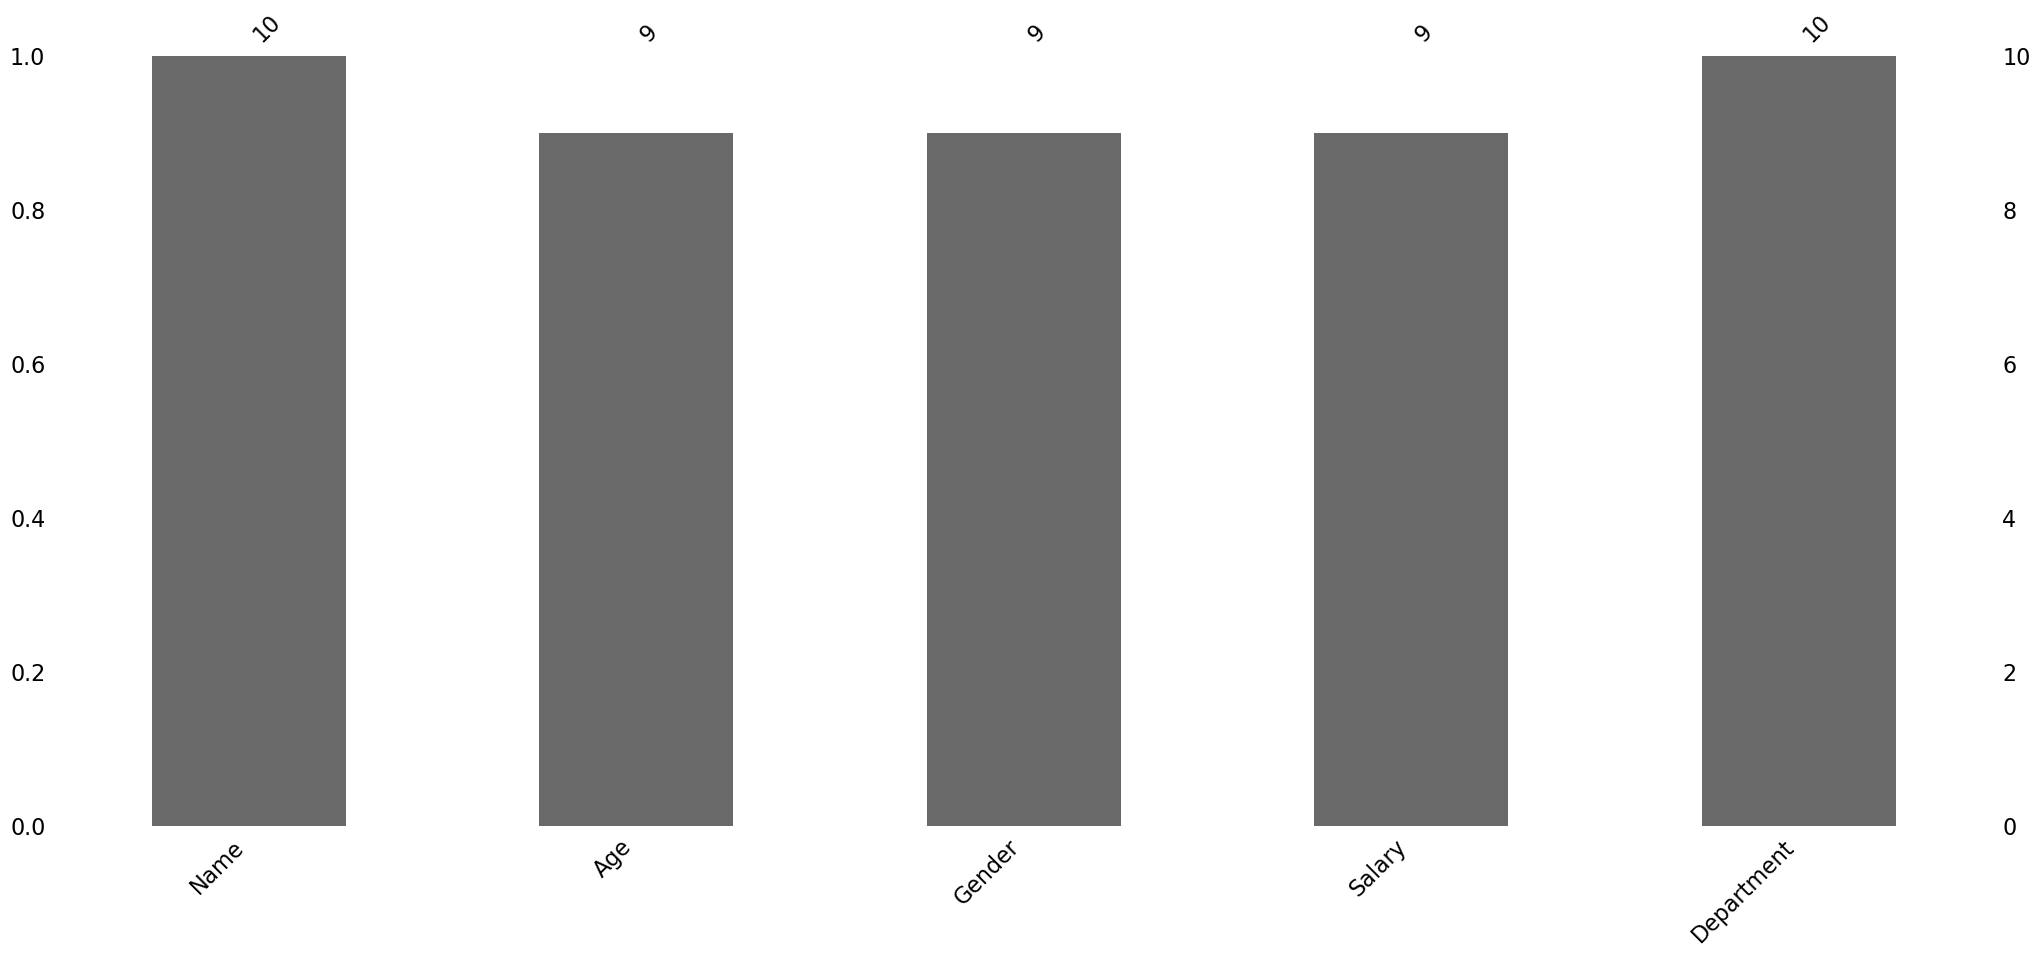

In [15]:
#To identify the missing values using visualization
import missingno as msno
msno.bar(df)

<Axes: >

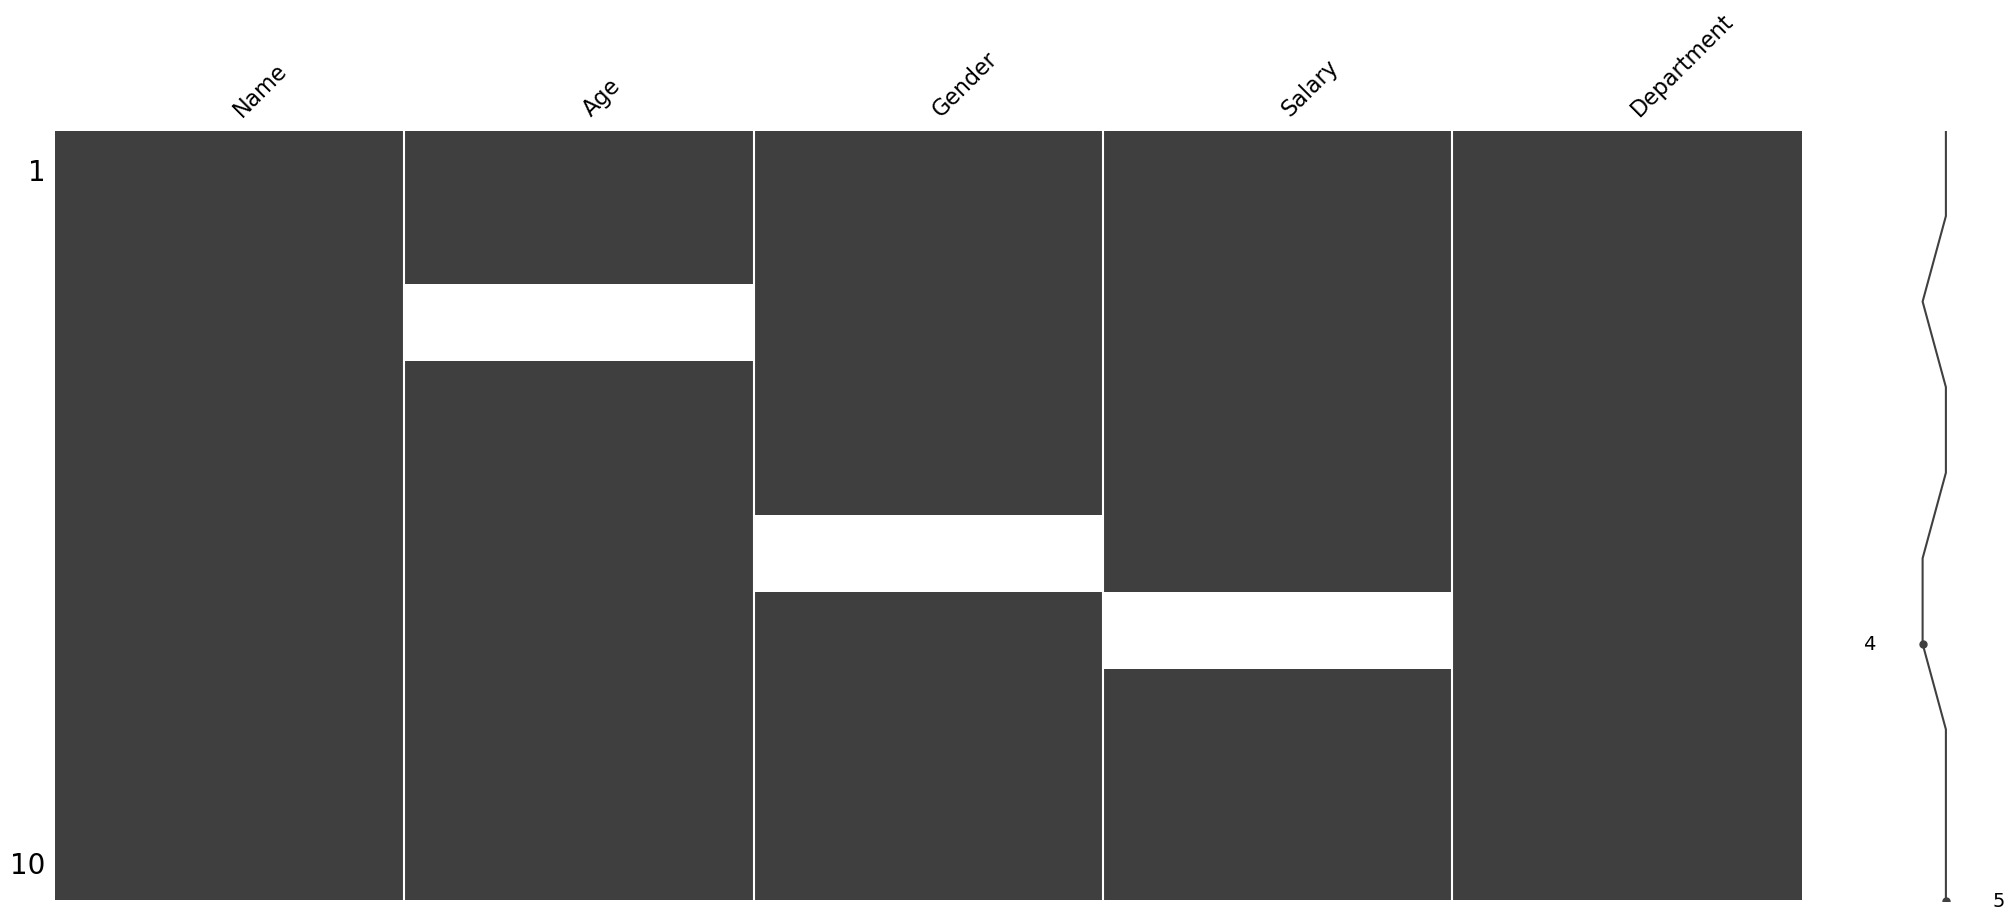

In [16]:
#To identify the missing values using matrix
msno.matrix(df)

<Axes: >

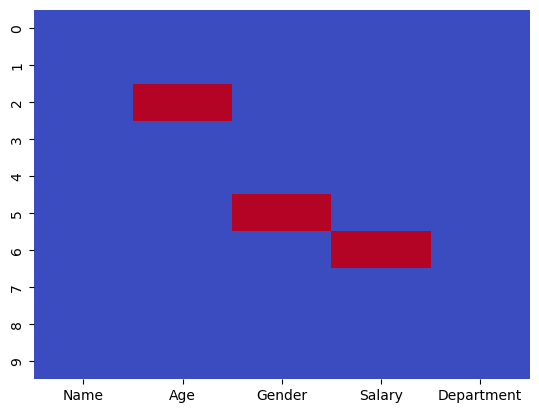

In [17]:
# Using various colour of heatmap
import seaborn as sns
sns.heatmap(df.isnull(),cbar=False,cmap='coolwarm')

<Axes: >

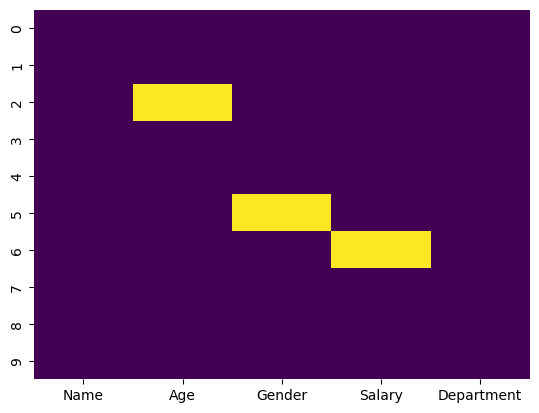

In [18]:
# Using various colour of heatmap
import seaborn as sns
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')

In [19]:
df2=df.copy()

In [20]:
df['Age']=df['Age'].fillna(df['Age'].mean())
df['Age']

0     25.000000
1     30.000000
2     39.555556
3     40.000000
4     22.000000
5     35.000000
6    120.000000
7     28.000000
8     29.000000
9     27.000000
Name: Age, dtype: float64

In [21]:
df['Age'].fillna(df['Age'].mean(),inplace=True)
df['Age']

0     25.000000
1     30.000000
2     39.555556
3     40.000000
4     22.000000
5     35.000000
6    120.000000
7     28.000000
8     29.000000
9     27.000000
Name: Age, dtype: float64

In [22]:
df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)
df['Gender']

C:\Users\USER\AppData\Local\Temp\ipykernel_9012\3966513486.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)


0    F
1    M
2    M
3    M
4    F
5    M
6    F
7    M
8    F
9    M
Name: Gender, dtype: object

In [23]:
# use mean for salary
df['Salary'].fillna(df['Salary'].mean(),inplace=True)
df['Salary']

C:\Users\USER\AppData\Local\Temp\ipykernel_9012\3926216428.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Salary'].fillna(df['Salary'].mean(),inplace=True)


0    50000.000000
1    60000.000000
2    55000.000000
3    58000.000000
4    52000.000000
5    61000.000000
6    57777.777778
7    59000.000000
8    63000.000000
9    62000.000000
Name: Salary, dtype: float64

In [24]:
#To check whether the missing values was Handled or not
df.isnull().sum()

Name          0
Age           0
Gender        0
Salary        0
Department    0
dtype: int64

<Axes: >

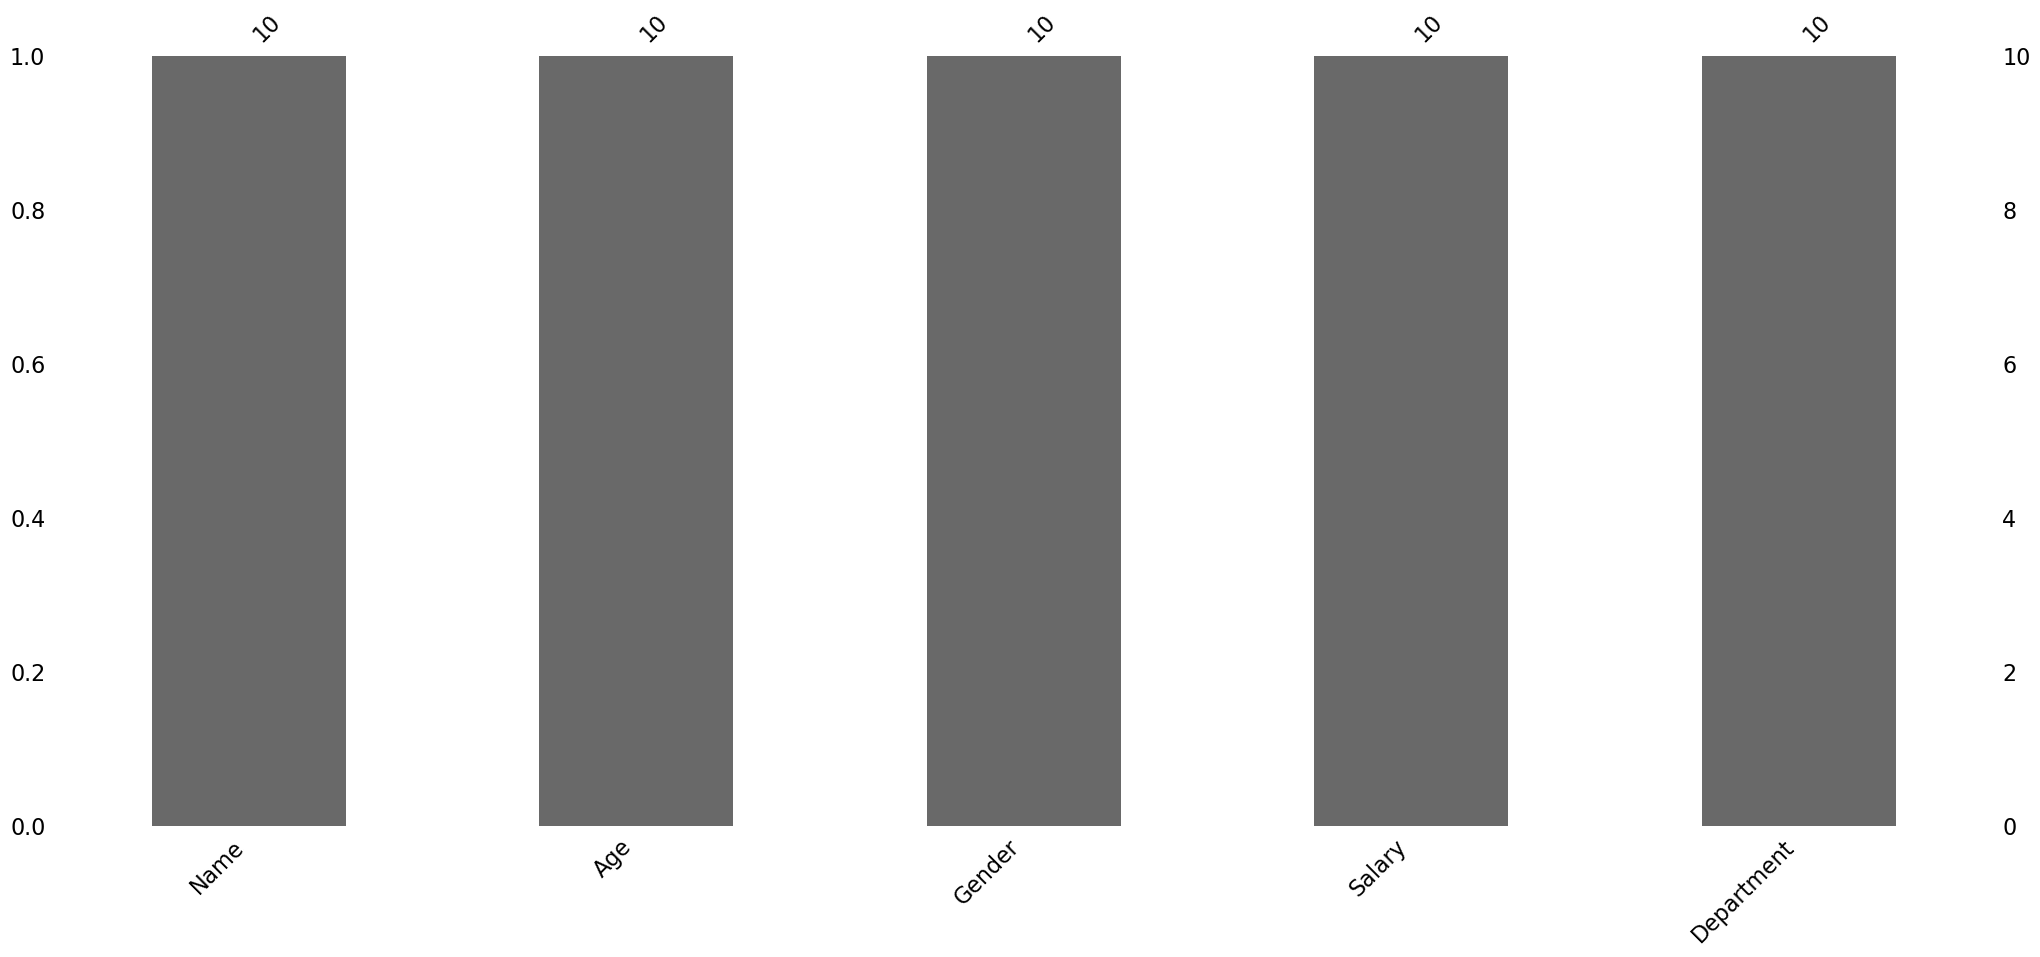

In [25]:
#To check whether the missing values was Handled or not
msno.bar(df)

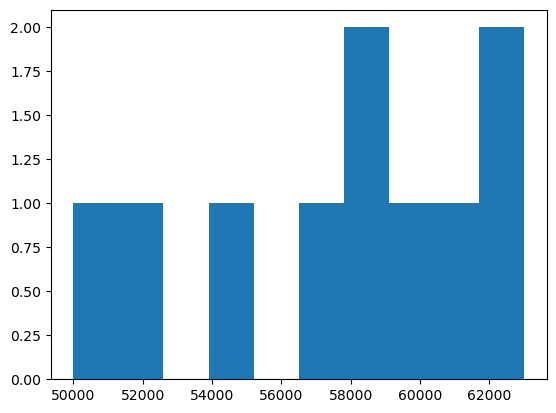

In [26]:
import matplotlib.pyplot as plt
plt.hist(df['Salary'])
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_9012\3249851952.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Salary'])


<Axes: xlabel='Salary', ylabel='Density'>

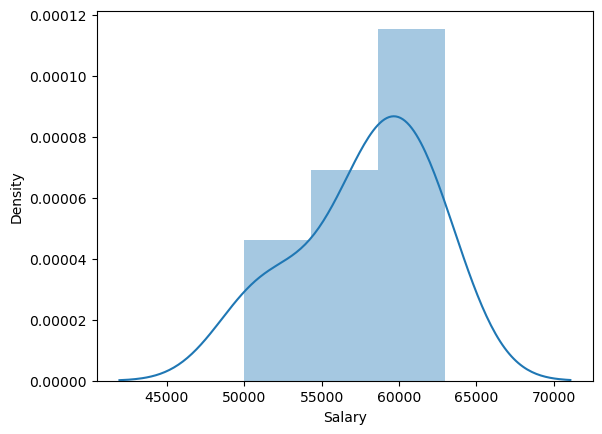

In [27]:
sns.distplot(df['Salary'])

In [28]:
# fill values using Simple Imputer
from sklearn.impute import SimpleImputer
imp=SimpleImputer(strategy='median')
df1[['Age']]=imp.fit_transform(df1[['Age']])
df

,Name,Age,Gender,Salary,Department
0,Alice,25.000000,F,50000.000000,HR
1,Bob,30.000000,M,60000.000000,Finance
2,Charlie,39.555556,M,55000.000000,IT
3,David,40.000000,M,58000.000000,HR
4,Eve,22.000000,F,52000.000000,IT
5,Frank,35.000000,M,61000.000000,Finance
6,Grace,120.000000,F,57777.777778,Finance
7,Henry,28.000000,M,59000.000000,HR
8,Ivy,29.000000,F,63000.000000,IT
9,Jack,27.000000,M,62000.000000,Finance


In [29]:
imp=SimpleImputer(strategy='mean')
df1[['Salary']]=imp.fit_transform(df1[['Salary']])
df1

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.000000,HR
1,Bob,30.0,M,60000.000000,Finance
2,Charlie,29.0,M,55000.000000,IT
3,David,40.0,M,58000.000000,HR
4,Eve,22.0,F,52000.000000,IT
5,Frank,35.0,NaN,61000.000000,Finance
6,Grace,120.0,F,57777.777778,Finance
7,Henry,28.0,M,59000.000000,HR
8,Ivy,29.0,F,63000.000000,IT
9,Jack,27.0,M,62000.000000,Finance


In [30]:
mp=SimpleImputer(strategy='most_frequent')
df1[['Gender']]=mp.fit_transform(df1[['Gender']])
df1

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.000000,HR
1,Bob,30.0,M,60000.000000,Finance
2,Charlie,29.0,M,55000.000000,IT
3,David,40.0,M,58000.000000,HR
4,Eve,22.0,F,52000.000000,IT
5,Frank,35.0,M,61000.000000,Finance
6,Grace,120.0,F,57777.777778,Finance
7,Henry,28.0,M,59000.000000,HR
8,Ivy,29.0,F,63000.000000,IT
9,Jack,27.0,M,62000.000000,Finance


<Axes: ylabel='Age'>

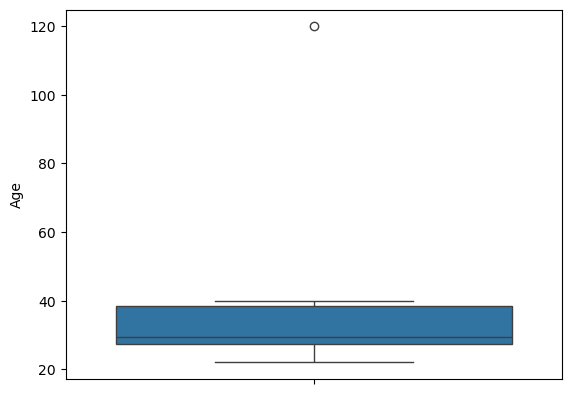

In [31]:
#Visualization of outliers by y axis
sns.boxplot(df['Age'])

<Axes: xlabel='Age'>

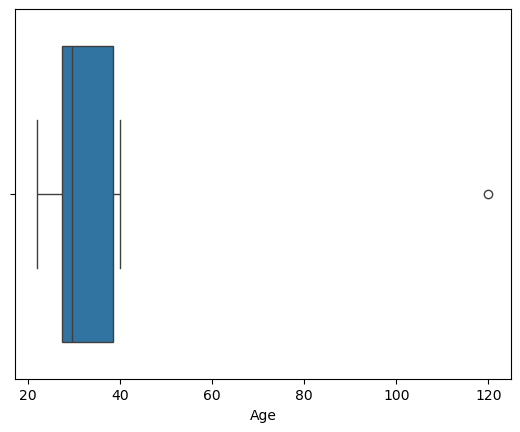

In [32]:
#Visualization of outliers by x axis
sns.boxplot(x=df['Age'])

In [33]:
q1=df['Age'].quantile(0.25)
q3=df['Age'].quantile(0.75)
iqr=q3-q1
lowbound=q1-1.5*iqr
uppbound=q3+1.5*iqr

outlier=df[(df['Age']<lowbound )|( df['Age']>uppbound)]
outlier

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,57777.777778,Finance


In [34]:
!pip install scipy

In [35]:
from scipy.stats import zscore
z=zscore(df['Age'])
import numpy as np
df[np.abs(z)>3]  # actual 3 and more than 3 if not works then use 2.9,2.8

,Name,Age,Gender,Salary,Department


In [36]:
from scipy.stats import zscore
z=zscore(df['Age'])
import numpy as np
df[np.abs(z)>2.9]  # actual 3 and more than 3 if not works then use 2.9,2.8

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,57777.777778,Finance


In [37]:
from scipy.stats import zscore
z=zscore(df['Age'])
import numpy as np
df[np.abs(z)>2.5]  # actual 3 and more than 3 if not works then use 2.9,2.8

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,57777.777778,Finance


In [38]:
from scipy.stats import zscore
z=zscore(df['Age'])
import numpy as np
df[np.abs(z)>3.1]  # actual 3 and more than 3 if not works then use 2.9,2.8

,Name,Age,Gender,Salary,Department


In [39]:
from sklearn.ensemble import IsolationForest
iso=IsolationForest(contamination=0.1)  # ranges from 0 to 0.5   higher contamination value then higher values will go to outlier
df['outlier']=iso.fit_predict(df[['Age','Salary']])  # a new column called outlier 
df[df['outlier']==-1]   # -1 represents that the outlier where present
                              
                        

,Name,Age,Gender,Salary,Department,outlier
6,Grace,120.0,F,57777.777778,Finance,-1


In [40]:
# Winsorization
from scipy.stats.mstats import winsorize
w=winsorize(df1['Age'],limits=[0.05,0.05])  # change the amount of percentile if the outliers where not handled
print(df1['Age'])
print(df)


0     25.0
1     30.0
2     29.0
3     40.0
4     22.0
5     35.0
6    120.0
7     28.0
8     29.0
9     27.0
Name: Age, dtype: float64
      Name         Age Gender        Salary Department  outlier
0    Alice   25.000000      F  50000.000000         HR        1
1      Bob   30.000000      M  60000.000000    Finance        1
2  Charlie   39.555556      M  55000.000000         IT        1
3    David   40.000000      M  58000.000000         HR        1
4      Eve   22.000000      F  52000.000000         IT        1
5    Frank   35.000000      M  61000.000000    Finance        1
6    Grace  120.000000      F  57777.777778    Finance       -1
7    Henry   28.000000      M  59000.000000         HR        1
8      Ivy   29.000000      F  63000.000000         IT        1
9     Jack   27.000000      M  62000.000000    Finance        1


In [41]:
# Winsorization

from scipy.stats.mstats import winsorize
w=winsorize(df['Age'],limits=[0.10,0.10])
df1['Age']

0     25.0
1     30.0
2     29.0
3     40.0
4     22.0
5     35.0
6    120.0
7     28.0
8     29.0
9     27.0
Name: Age, dtype: float64

In [42]:
# Winsorization
from scipy.stats.mstats import winsorize
w=winsorize(df['Age'],limits=[0.10,0.10])
df1['Age']

0     25.0
1     30.0
2     29.0
3     40.0
4     22.0
5     35.0
6    120.0
7     28.0
8     29.0
9     27.0
Name: Age, dtype: float64

In [43]:
#winsorization without scipy or librarie
lower=df['Age'].quantile(0.5)
upper=df['Age'].quantile(0.95)
df['Age']=df['Age'].clip(lower,upper)
df['Age']

0    29.500000
1    30.000000
2    39.555556
3    40.000000
4    29.500000
5    35.000000
6    40.000000
7    29.500000
8    29.500000
9    29.500000
Name: Age, dtype: float64

In [44]:
# Log transformation
import numpy as np
df1['new Age']=np.log(df['Age'])
df1['new Age']

0    3.384390
1    3.401197
2    3.677706
3    3.688879
4    3.384390
5    3.555348
6    3.688879
7    3.384390
8    3.384390
9    3.384390
Name: new Age, dtype: float64

In [45]:
#Power Transformation using yeo-johnson method
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer()  # by default it uses yeo-johnson method 
df1['new Age']=pt.fit_transform(df[['Age']])
df1['new Age']

0   -0.843535
1   -0.612152
2    1.324667
3    1.358730
4   -0.843535
5    0.787702
6    1.358730
7   -0.843535
8   -0.843535
9   -0.843535
Name: new Age, dtype: float64

In [46]:
#Power Transformation using yeo-johnson method
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
df1['new Age']=pt.fit_transform(df[['Age']])
df1['new Age']

0   -0.843535
1   -0.612152
2    1.324667
3    1.358730
4   -0.843535
5    0.787702
6    1.358730
7   -0.843535
8   -0.843535
9   -0.843535
Name: new Age, dtype: float64

In [47]:
# Power Transformation using boxcox method
pt=PowerTransformer(method='box-cox')
df1['new age']=pt.fit_transform(df1[['Age']])
df1['new age']

0   -0.910604
1    0.045799
2   -0.106151
3    0.987200
4   -1.828669
5    0.618128
6    2.038488
7   -0.274931
8   -0.106151
9   -0.463109
Name: new age, dtype: float64

In [48]:
# Boxcox
from scipy.stats import boxcox
df1["Age new"],lam=boxcox(df1['Age'])
df1["Age new"]

0    0.488415
1    0.488626
2    0.488593
3    0.488834
4    0.488213
5    0.488752
6    0.489066
7    0.488555
8    0.488593
9    0.488514
Name: Age new, dtype: float64

In [49]:
# Standard scaler
from sklearn.preprocessing import StandardScaler
s=StandardScaler()   # scales the values from the range of -1 to 1
df1['new age']=s.fit_transform(df1[['Age']])
df1['new age']

0   -0.489487
1   -0.308196
2   -0.344454
3    0.054387
4   -0.598262
5   -0.126904
6    2.955052
7   -0.380712
8   -0.344454
9   -0.416971
Name: new age, dtype: float64

In [50]:
#Normalization
from sklearn.preprocessing import MinMaxScaler
mm=MinMaxScaler()   # scales the values from 0 t0 1
df1['new age']=mm.fit_transform(df1[['Age']])
df1['new age']

0    0.030612
1    0.081633
2    0.071429
3    0.183673
4    0.000000
5    0.132653
6    1.000000
7    0.061224
8    0.071429
9    0.051020
Name: new age, dtype: float64

In [51]:
df

,Name,Age,Gender,Salary,Department,outlier
0,Alice,29.500000,F,50000.000000,HR,1
1,Bob,30.000000,M,60000.000000,Finance,1
2,Charlie,39.555556,M,55000.000000,IT,1
3,David,40.000000,M,58000.000000,HR,1
4,Eve,29.500000,F,52000.000000,IT,1
5,Frank,35.000000,M,61000.000000,Finance,1
6,Grace,40.000000,F,57777.777778,Finance,-1
7,Henry,29.500000,M,59000.000000,HR,1
8,Ivy,29.500000,F,63000.000000,IT,1
9,Jack,29.500000,M,62000.000000,Finance,1


In [52]:
#Encoding 
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
lb.fit_transform(df['Gender']) 
df

,Name,Age,Gender,Salary,Department,outlier
0,Alice,29.500000,F,50000.000000,HR,1
1,Bob,30.000000,M,60000.000000,Finance,1
2,Charlie,39.555556,M,55000.000000,IT,1
3,David,40.000000,M,58000.000000,HR,1
4,Eve,29.500000,F,52000.000000,IT,1
5,Frank,35.000000,M,61000.000000,Finance,1
6,Grace,40.000000,F,57777.777778,Finance,-1
7,Henry,29.500000,M,59000.000000,HR,1
8,Ivy,29.500000,F,63000.000000,IT,1
9,Jack,29.500000,M,62000.000000,Finance,1


In [53]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
df['Encoded Gender']=lb.fit_transform(df['Gender']) # To identify the difference
df

,Name,Age,Gender,Salary,Department,outlier,Encoded Gender
0,Alice,29.500000,F,50000.000000,HR,1,0
1,Bob,30.000000,M,60000.000000,Finance,1,1
2,Charlie,39.555556,M,55000.000000,IT,1,1
3,David,40.000000,M,58000.000000,HR,1,1
4,Eve,29.500000,F,52000.000000,IT,1,0
5,Frank,35.000000,M,61000.000000,Finance,1,1
6,Grace,40.000000,F,57777.777778,Finance,-1,0
7,Henry,29.500000,M,59000.000000,HR,1,1
8,Ivy,29.500000,F,63000.000000,IT,1,0
9,Jack,29.500000,M,62000.000000,Finance,1,1


In [54]:
from sklearn.preprocessing import OneHotEncoder 
oh=OneHotEncoder(sparse_output=False)  # takes all data as array  and easy understanding
df['Encoded Gender']=oh.fit_transform(df[['Gender']]) 
df

,Name,Age,Gender,Salary,Department,outlier,Encoded Gender
0,Alice,29.500000,F,50000.000000,HR,1,1.0
1,Bob,30.000000,M,60000.000000,Finance,1,0.0
2,Charlie,39.555556,M,55000.000000,IT,1,0.0
3,David,40.000000,M,58000.000000,HR,1,0.0
4,Eve,29.500000,F,52000.000000,IT,1,1.0
5,Frank,35.000000,M,61000.000000,Finance,1,0.0
6,Grace,40.000000,F,57777.777778,Finance,-1,1.0
7,Henry,29.500000,M,59000.000000,HR,1,0.0
8,Ivy,29.500000,F,63000.000000,IT,1,1.0
9,Jack,29.500000,M,62000.000000,Finance,1,0.0


In [59]:
from sklearn.preprocessing import OneHotEncoder 
oh=OneHotEncoder(sparse_output=True)  #  Take as sparse matrix and takes ony non zero values difficult understanding
encode=oh.fit_transform(df[['Gender']])
df  

,Name,Age,Gender,Salary,Department,outlier,Encoded Gender
0,Alice,29.500000,F,50000.000000,HR,1,1.0
1,Bob,30.000000,M,60000.000000,Finance,1,0.0
2,Charlie,39.555556,M,55000.000000,IT,1,0.0
3,David,40.000000,M,58000.000000,HR,1,0.0
4,Eve,29.500000,F,52000.000000,IT,1,1.0
5,Frank,35.000000,M,61000.000000,Finance,1,0.0
6,Grace,40.000000,F,57777.777778,Finance,-1,1.0
7,Henry,29.500000,M,59000.000000,HR,1,0.0
8,Ivy,29.500000,F,63000.000000,IT,1,1.0
9,Jack,29.500000,M,62000.000000,Finance,1,0.0


In [56]:
#get dummies
df11=pd.get_dummies(df,columns=['Gender'],drop_first=True) #Drop 
df11

,Name,Age,Salary,Department,outlier,Encoded Gender,Gender_M
0,Alice,29.500000,50000.000000,HR,1,1.0,False
1,Bob,30.000000,60000.000000,Finance,1,0.0,True
2,Charlie,39.555556,55000.000000,IT,1,0.0,True
3,David,40.000000,58000.000000,HR,1,0.0,True
4,Eve,29.500000,52000.000000,IT,1,1.0,False
5,Frank,35.000000,61000.000000,Finance,1,0.0,True
6,Grace,40.000000,57777.777778,Finance,-1,1.0,False
7,Henry,29.500000,59000.000000,HR,1,0.0,True
8,Ivy,29.500000,63000.000000,IT,1,1.0,False
9,Jack,29.500000,62000.000000,Finance,1,0.0,True


In [57]:
# Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df1['Encoded Gender']=oe.fit_transform(df[['Gender']])
df1

,Name,Age,Gender,Salary,Department,new Age,new age,Age new,Encoded Gender
0,Alice,25.0,F,50000.000000,HR,-0.843535,0.030612,0.488415,0.0
1,Bob,30.0,M,60000.000000,Finance,-0.612152,0.081633,0.488626,1.0
2,Charlie,29.0,M,55000.000000,IT,1.324667,0.071429,0.488593,1.0
3,David,40.0,M,58000.000000,HR,1.358730,0.183673,0.488834,1.0
4,Eve,22.0,F,52000.000000,IT,-0.843535,0.000000,0.488213,0.0
5,Frank,35.0,M,61000.000000,Finance,0.787702,0.132653,0.488752,1.0
6,Grace,120.0,F,57777.777778,Finance,1.358730,1.000000,0.489066,0.0
7,Henry,28.0,M,59000.000000,HR,-0.843535,0.061224,0.488555,1.0
8,Ivy,29.0,F,63000.000000,IT,-0.843535,0.071429,0.488593,0.0
9,Jack,27.0,M,62000.000000,Finance,-0.843535,0.051020,0.488514,1.0
